In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df = pd.read_csv('/content/drive/MyDrive/loan_data.csv')
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [48]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [49]:


print(df[df["person_age"] > 100])

       person_age person_gender person_education  person_income  \
81            144          male         Bachelor         300616   
183           144          male        Associate         241424   
575           123        female      High School          97140   
747           123          male         Bachelor          94723   
32297         144        female        Associate        7200766   
37930         116          male         Bachelor        5545545   
38113         109          male      High School        5556399   

       person_emp_exp person_home_ownership  loan_amnt loan_intent  \
81                125                  RENT       4800     VENTURE   
183               121              MORTGAGE       6000   EDUCATION   
575               101                  RENT      20400   EDUCATION   
747               100                  RENT      20000     VENTURE   
32297             124              MORTGAGE       5000    PERSONAL   
37930              93              MORTGAGE

In [50]:
print((df["person_age"] > 100).sum())

7


In [51]:
df = df[df["person_age"] <= 100]

In [52]:
df.shape

(44993, 14)

In [53]:

print((df["person_age"] > 100).sum())

0


In [54]:
print((df["person_emp_exp"] > 60).sum())

3


In [55]:
df = df[df["person_emp_exp"] <= 60]

In [56]:
print((df["person_emp_exp"] > 60).sum())

0


In [57]:
df.shape

(44990, 14)

In [84]:



df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 44990 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44990 non-null  int64  
 1   person_gender                   44990 non-null  int64  
 2   person_education                44990 non-null  int64  
 3   person_income                   44990 non-null  int64  
 4   person_emp_exp                  44990 non-null  int64  
 5   person_home_ownership           44990 non-null  int64  
 6   loan_amnt                       44990 non-null  int64  
 7   loan_intent                     44990 non-null  int64  
 8   loan_int_rate                   44990 non-null  float64
 9   loan_percent_income             44990 non-null  float64
 10  cb_person_cred_hist_length      44990 non-null  int64  
 11  credit_score                    44990 non-null  int64  
 12  previous_loan_defaults_on_file  44990

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [85]:
df.describe()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,44990.000000,44990.000000,44990.000000,4.499000e+04,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000
mean,27.744543,0.551967,1.743921,7.990883e+04,5.390465,1.696666,9583.297888,2.525672,11.006510,0.139737,5.865259,632.578329,0.508002,0.222272
std,5.890563,0.497298,1.479195,6.332359e+04,5.906165,1.440480,6314.982527,1.728279,2.979037,0.087208,3.874023,50.394327,0.499942,0.415777
min,20.000000,0.000000,0.000000,8.000000e+03,0.000000,0.000000,500.000000,0.000000,5.420000,0.000000,2.000000,390.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,4.719575e+04,1.000000,0.000000,5000.000000,1.000000,8.590000,0.070000,3.000000,601.000000,0.000000,0.000000
50%,26.000000,1.000000,1.000000,6.704550e+04,4.000000,3.000000,8000.000000,3.000000,11.010000,0.120000,4.000000,640.000000,1.000000,0.000000
75%,30.000000,1.000000,3.000000,9.577700e+04,8.000000,3.000000,12237.750000,4.000000,12.990000,0.190000,8.000000,670.000000,1.000000,0.000000
max,78.000000,1.000000,4.000000,2.448661e+06,58.000000,3.000000,35000.000000,5.000000,20.000000,0.660000,30.000000,784.000000,1.000000,1.000000


Exploratory Data Analysis

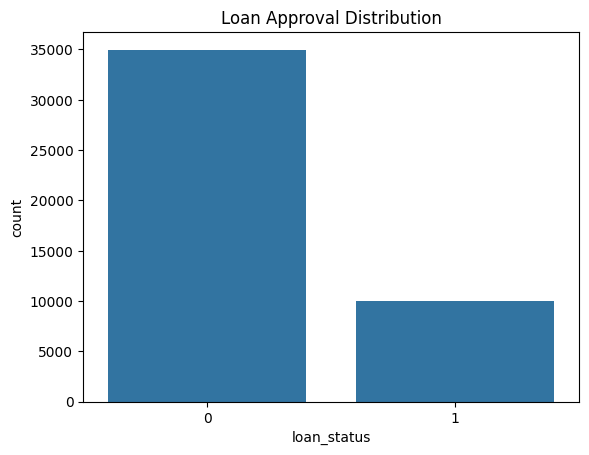

In [58]:
#Target Distribution
sns.countplot(
    x="loan_status",
    data=df
)

plt.title("Loan Approval Distribution")
plt.show()

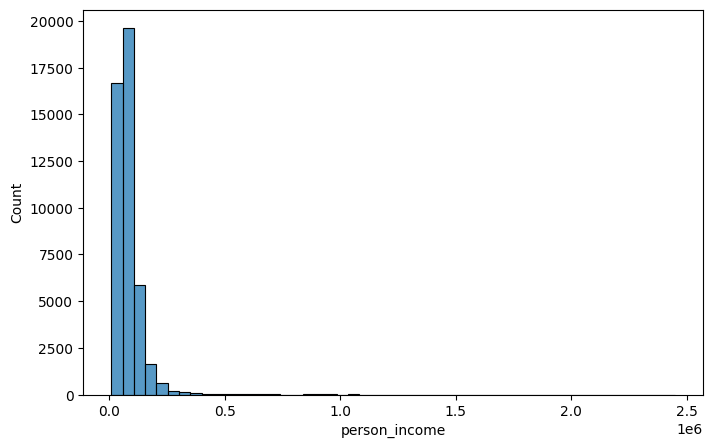

In [59]:
#Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["person_income"],
    bins=50
)

plt.show()

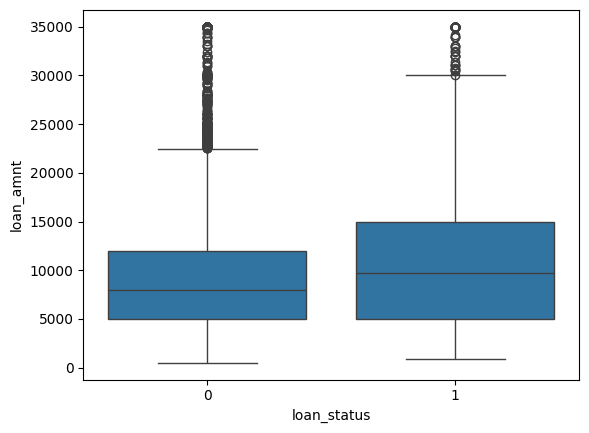

In [60]:
#Loan Amount Analysis
sns.boxplot(
    x="loan_status",
    y="loan_amnt",
    data=df
)

plt.show()

Handle Missing Values

In [61]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [62]:
df.fillna(
    df.median(numeric_only=True),
    inplace=True
)
for col in df.select_dtypes('object'):
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

/tmp/ipykernel_1047/2924147002.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


Encode Categorical Variables

In [63]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.select_dtypes("object"):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [64]:
for key, encoder in encoders.items():
    print(key, ":", encoder.classes_)

person_gender : ['female' 'male']
person_education : ['Associate' 'Bachelor' 'Doctorate' 'High School' 'Master']
person_home_ownership : ['MORTGAGE' 'OTHER' 'OWN' 'RENT']
loan_intent : ['DEBTCONSOLIDATION' 'EDUCATION' 'HOMEIMPROVEMENT' 'MEDICAL' 'PERSONAL'
 'VENTURE']
previous_loan_defaults_on_file : ['No' 'Yes']


In [65]:
print(df.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [66]:
import pickle

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [67]:
from google.colab import files

files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Split Features and Target

In [68]:
X = df.drop(
    "loan_status",
    axis=1
)
y = df["loan_status"]


In [69]:
print(X.columns.tolist())
print("Number of features:", X.shape[1])

['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Number of features: 13


Feature Scaling

In [70]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Build ANN Model

In [72]:
model = Sequential()


model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)


model.add(
    Dropout(0.3)
)


model.add(
    Dense(
        64,
        activation="relu"
    )
)


model.add(
    Dense(
        32,
        activation="relu"
    )
)


model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [73]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train ANN

In [99]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
     callbacks=[early_stop]
)

Epoch 1/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9281 - loss: 0.1581 - val_accuracy: 0.9164 - val_loss: 0.1920
Epoch 2/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9290 - loss: 0.1569 - val_accuracy: 0.9150 - val_loss: 0.1917
Epoch 3/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9296 - loss: 0.1583 - val_accuracy: 0.9140 - val_loss: 0.1897
Epoch 4/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9278 - loss: 0.1587 - val_accuracy: 0.9151 - val_loss: 0.1899
Epoch 5/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9283 - loss: 0.1575 - val_accuracy: 0.9153 - val_loss: 0.1901
Epoch 6/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9298 - loss: 0.1582 - val_accuracy: 0.9160 - val_loss: 0.1976
Epoch 7/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9285 - loss: 0.1583 - val_accuracy: 0.9128 - val_loss: 0.1938
Epoch 8/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9289 - loss: 0.1569 - val_accuracy: 0.

Model Evaluation

In [100]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",accuracy)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9139 - loss: 0.1908
Accuracy: 0.9138697385787964


In [101]:
y_pred = model.predict(X_test)

y_pred = (y_pred>0.5).astype(int)

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Classification Report

In [77]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      6998
           1       0.87      0.72      0.79      2000

    accuracy                           0.92      8998
   macro avg       0.90      0.85      0.87      8998
weighted avg       0.91      0.92      0.91      8998



Confusion Matrix

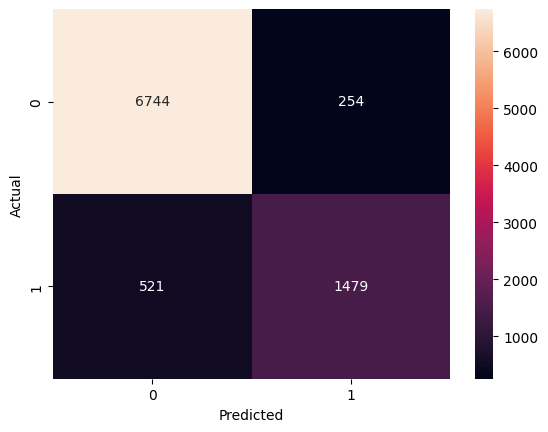

In [102]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC-AUC Score

In [103]:
prob = model.predict(X_test)

roc_auc_score(
    y_test,
    prob
)

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


np.float64(0.9651370034295512)

Save Model

In [104]:
model.save(
    "loan_ann_model.keras"
)

In [105]:
from google.colab import files
files.download("loan_ann_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
import pickle

pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)

In [83]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>